# || NEMO PIPELINE Workstation  ||
© _Konstantinos Andreadis_ (Roux Lab & Salbreux Lab @UNIGE)

In [33]:
# Import custom scripts
from scripts import analysis, datahandler, visuals, simulation
from importlib import reload

for module in (analysis, datahandler, visuals, simulation):
    reload(module)

# Import python essentials
import os
import numpy as np
import matplotlib.pyplot as plt
import trimesh

# --Import Image--

In [46]:
reload(analysis)
hyperstack_dimensions = analysis.load_img_dimensions(
    path="/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff")
c_projection_range = np.arange(hyperstack_dimensions["C"])

>> Importing /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff...
T = 1, Z = 300, C = 1, Y = 300, X = 300


Selected image path: /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif
>> Importing /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif...
Found 5D TZCYX Hyperstack | (4, 40, 3, 1024, 1024) | 503.32 MB !
Found xscale = 0.4143214347122641, yscale = 0.4143214347122641 !
Found zscale = 4.0 !
Found image scale = (4.0, 0.4143214347122641, 0.4143214347122641) !
>> Overwriting unit with um...
>> Selecting Z-Stack at T=0 C=0 ...
Loaded T=0 C=0 Z-stack (41.94 MB) !
>> Plotting slices...


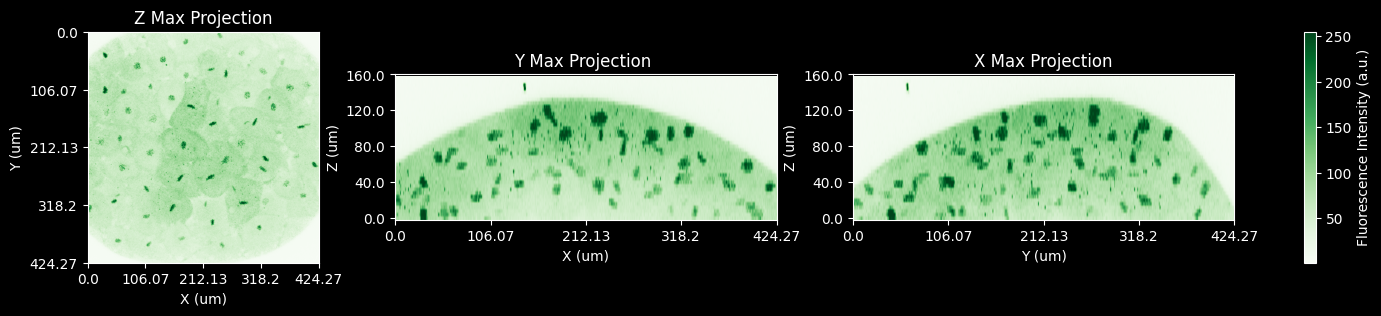

>> Plotting slices...


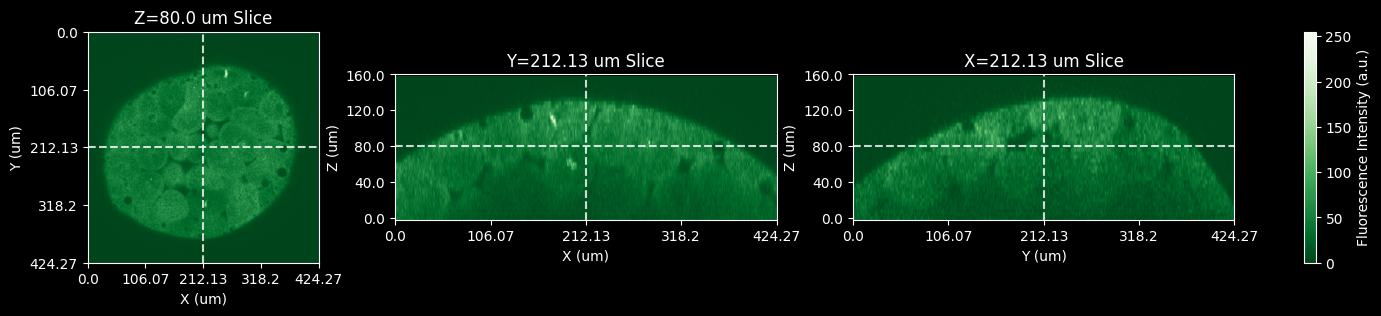

>> Rendering image...


In [14]:
# ==== Choose Image ====
# [!] WINDOWS: Sometimes the r before the file path string is needed, no idea why.
img_path = r""
img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/2023/Live_nuclei/nuclei.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/DEBUG/debug.tiff"

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/72.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/96.tif"
# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/1_gastruloid/segmentation_examples/120.tif"

# img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/oriane/fish2_scale1_3dpp_SHGt.tif"
# img_path = r"/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/0_capsule/clean_multi-layer/sphere_mx_denoised_cleaned.tif"

img_path = "/Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13.tif"
print(f"Selected image path: {img_path}")

# ==== Choose Time Step and Channel ====
t_select = 0
c_select = 0

# ==== Optional: Reduce Resolution ====
z_reduce_factor = 1  # 1 means no reduction
xy_reduce_factor = 1  # 1 means no reduction

# ==== Optional: Normalise Intensities to [0, 1] ====
normalise_intensities = False  # can be set to False

# ==== Optional: Overwrite Scaling with FIJI Values ====
custom_scaling = None  # please use (z, y, x)

# ==== Optional: Overwrite unit with FIJI Values ====
custom_unit = "um"  # as string

# ==== Load Image ====
img_load = analysis.load_img_virtual(path=img_path, t_sel_idx=t_select,
                                     c_sel_idx=c_select, reduce_xy=xy_reduce_factor,
                                     reduce_z=z_reduce_factor, norm_vals=normalise_intensities,
                                     custom_scaling=custom_scaling,
                                     custom_unit=custom_unit)
if img_load is not None:
    img_raw, img_dim, img_scale, img_unit = img_load

    # ==== Create Folder Structure ====
    resdata_dir, resfig_dir = datahandler.create_resdirs(img_path)

    # ==== Optional: Pad Image above & below Z/Y/X with 0s ====
    # z_pad = 5
    # img_raw = np.pad(img_raw, pad_width=((z_pad, z_pad), (0, 0), (0, 0)), mode='constant')
    # img_dim = img_raw.shape

    # ==== Optional: Crop Image ====
    # img_raw = img_raw[:50, :, :]
    # img_dim = img_raw.shape

    # ==== Plot Image Slices and Max Projections ====
    visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, max_proj=True, cmap='Greens',
                     savefig=os.path.join(resfig_dir, "sliced_maxproj_raw.png"))
    # z_i, y_i, x_i = int(200 / img_scale[0]), int(570 / img_scale[1]), int(455 / img_scale[2])
    z_i, y_i, x_i = int(img_dim[0] // 2), int(img_dim[1] // 2), int(img_dim[2] // 2)
    visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, x_i=x_i, y_i=y_i, z_i=z_i,
                     savefig=os.path.join(resfig_dir, "sliced_raw.png"), cmap="Greens_r")

    # ==== 3D Render Image ====
    # visuals.view_img(img_list=[img_raw], title_list=["Raw Image"], scale=img_scale)
else:
    img_raw, img_dim, img_scale, img_unit = np.zeros((1, 1, 1)), (1, 1, 1), (1, 1, 1), "?"
    resdata_dir, resfig_dir = None, None

# Create Mesh

## |1| Image Blur & Threshold

>> Applying 3D Gaussian blur with sigma = (0.8286428694245283, 8, 8)...
>> Plotting slices...


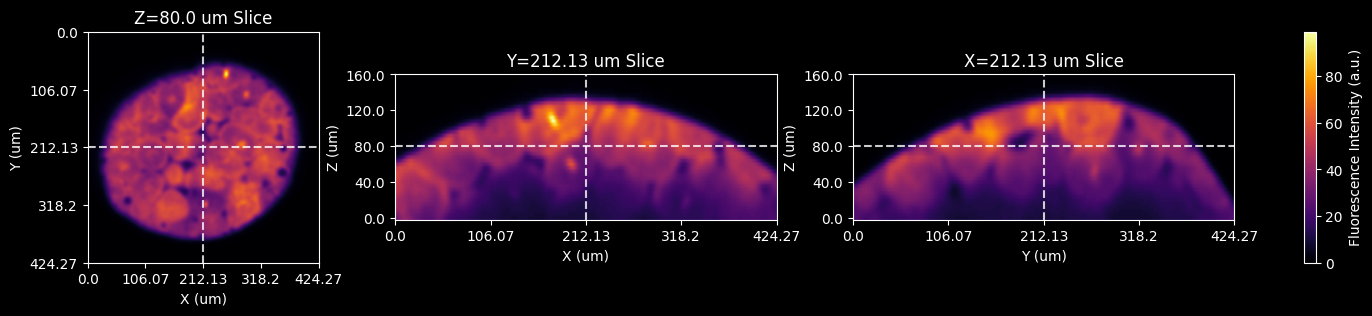

In [15]:
# ==== Blur Image ====
sigma = 8
sigma_ = analysis.rescale_val_xyz(val=sigma, scale=img_scale)
img_blur = analysis.gaussian_blur(img=img_raw, sigma=sigma_, renorm=False)

# ==== Plot Image Slices ====
visuals.plot_img(img=img_blur, scale=img_scale, unit=img_unit, cmap="inferno",
                 savefig=os.path.join(resfig_dir, "sliced_blur.png"))

# ==== 3D Render Image ====
# visuals.view_img([img_blur], scale=img_scale, title_list=["Blurred Image"])

>> Applying threshold 3.7...
>> Plotting slices...


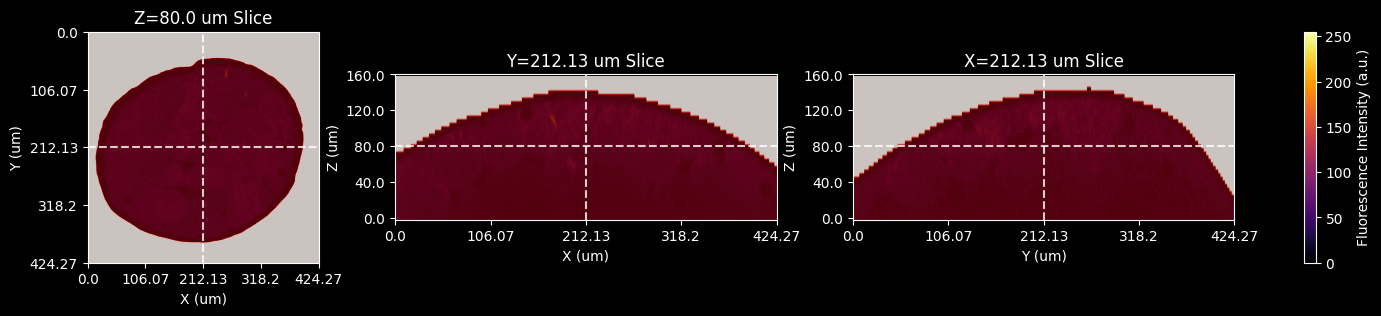

In [16]:
# ==== Yen Threshold Image ====
# img_thresh_val = np.min([analysis.yen_thresh(img_blur[:, :, img_dim[2] // i]) for i in np.arange(2, 6)])
img_thresh_val = np.min(
    [analysis.yen_thresh(img_blur[:, :, img_dim[2] // 2]),
     analysis.yen_thresh(img_blur[:, img_dim[1] // 2, :]),
     analysis.yen_thresh(img_blur[img_dim[0] // 2, :, :])])
img_thresh_val *= 0.1

# img_thresh_val = np.min([analysis.yen_thresh(img_blur[:, :, int(img_dim[2] * i)]) for i in np.linspace(0.4, 0.6, 10)])

# ==== Binarise Image using Threshold ====
img_thresh = analysis.thresh_img(img_blur, img_thresh_val)

# ==== Plot Image Slices ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, savefig=os.path.join(resfig_dir, "sliced_thresh.png"),
                 cmap="inferno", thresh_mask=img_thresh)

# ==== 3D Render Image ====
# visuals.view_img([img_thresh], scale=img_scale, title_list=["Thresholded Image"])

In [ ]:
# # ==== Optional: Fill Holes in Binary Image ====
# img_thresh = analysis.fill_holes_img(img_thresh)
#
# # ==== Plot Image Slices ====
# visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
#                  savefig=os.path.join(resfig_dir, "sliced_thresh.png"),
#                  cmap="inferno", thresh_mask=img_thresh)

In [ ]:
# # ==== Optional: Save Thresholded Raw Image as .tiff ====
# visuals.view_img([img_raw, img_thresh], opacity_list=[1.0, 0.6], color_list=["green", "Blues"], scale=img_scale,
#                  title_list=["Raw Image", "Thresholded Image"])
# img_thresh = analysis.thresh_img(img_raw, img_thresh_val, keep_values_above=True)
# datahandler.save_tiff(img_thresh, filepath=os.path.join(resfig_dir, "thresh_img.tiff"))

## |2| Surface Mesh Extraction

>> Extracting mesh(es) using marching cubes algorithm with box size 2...
>> Identifying surfaces using mask...
>> Identifying surfaces using mask...
>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/full_mesh.ply...
>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/inner_mesh.ply...
>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/outer_mesh.ply...
Number of vertices: #INNER = 274156 + #OUTER = 156 == #FULL = 274318!
>> Plotting slices...


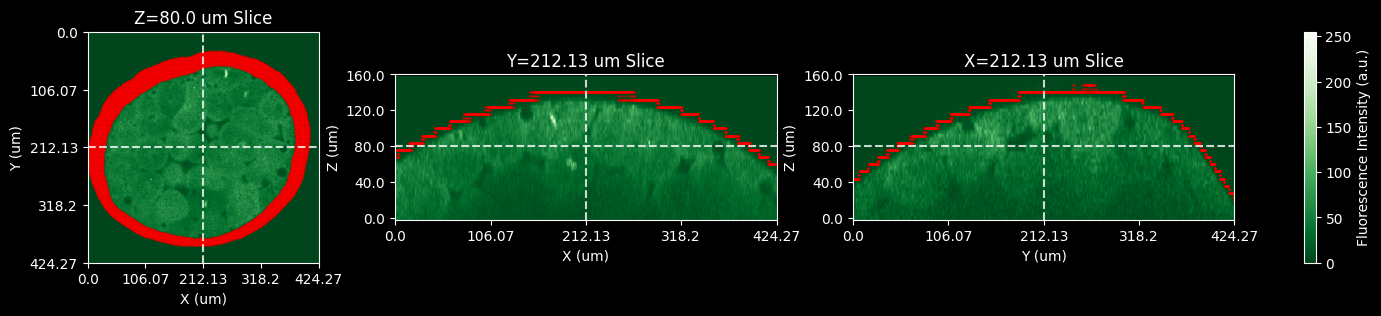

In [17]:
# ==== Segment Surface Mesh(es) ====
mcub_res = 2
full_mesh = analysis.marching_cubes(img=img_thresh, scale=img_scale, level=0.5, step_size=mcub_res)

# ==== Select INNER / OUTER Mesh ====
mesh_sel_mask = np.einsum('ij,ij->i', full_mesh.vertices - np.mean(full_mesh.vertices, axis=0),
                          full_mesh.vertex_normals) > 0

# ==== Select TOP / BOTTOM Mesh ====
mesh_sel_mask = np.einsum('ij,ij->i', np.array([[1, 0, 0] for i in range(len(full_mesh.vertices))]),
                          full_mesh.vertex_normals) < 0

# ==== Apply Sub-Mesh Selection ====
inner_mesh = analysis.sel_submesh(mesh=full_mesh, mask=mesh_sel_mask)
outer_mesh = analysis.sel_submesh(mesh=full_mesh, mask=~mesh_sel_mask)

# ==== Save Mesh(es) ====
datahandler.save_mesh(full_mesh, os.path.join(resdata_dir, "full_mesh.ply"))
datahandler.save_mesh(inner_mesh, os.path.join(resdata_dir, "inner_mesh.ply"))
datahandler.save_mesh(outer_mesh, os.path.join(resdata_dir, "outer_mesh.ply"))
print(
    f"Number of vertices: #INNER = {inner_mesh.vertices.shape[0]} + #OUTER = {outer_mesh.vertices.shape[0]} == #FULL = {full_mesh.vertices.shape[0]}!")

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_raw_full-mesh.png"), meshes=[inner_mesh, outer_mesh],
                 mesh_colors=["red", "blue"])

In [19]:
# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[full_mesh, inner_mesh], mesh_colors=["white", "red"],
#                   mesh_titles=["Full Mesh", "Inner Mesh"], mesh_opacities=[0.3, 0.3], vec_freq=5,
#                   img=img_raw, img_opacity=0.5, scale=img_scale)
# visuals.view_mesh(mesh_list=[inner_mesh, outer_mesh], mesh_colors=["red", "blue"],
#                   mesh_titles=["Inner Mesh", "Outer Mesh"], mesh_opacities=[0.3, 0.3], vec_freq=5,
#                   img=img_raw, img_opacity=0.5, scale=img_scale)

>> Rendering mesh...


## |3| Mesh Processing

>> Taubin smoothing mesh with 200 iterations and pass band 0.001...
>> Taubin smoothing mesh with 200 iterations and pass band 0.001...
>> Taubin smoothing mesh with 200 iterations and pass band 0.001...
>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/full_mesh_smooth.ply...
>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/inner_mesh_smooth.ply...
>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/outer_mesh_smooth.ply...
>> Plotting slices...


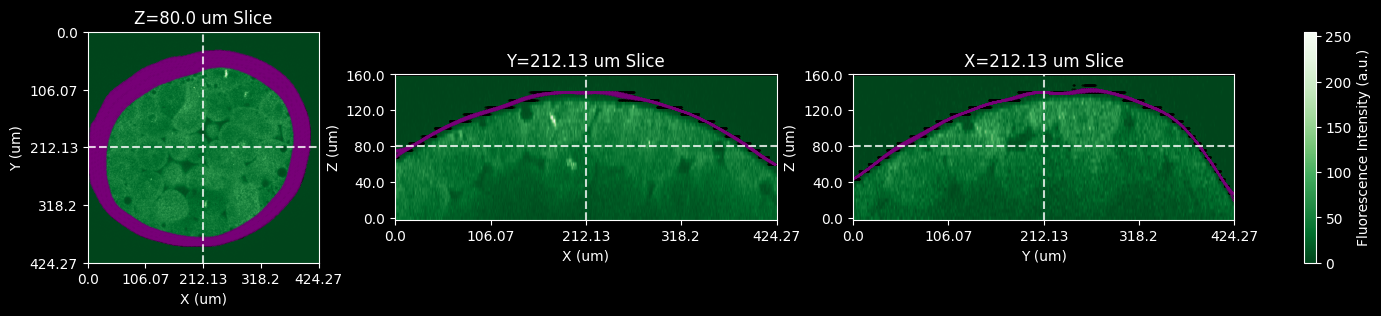

>> Plotting slices...


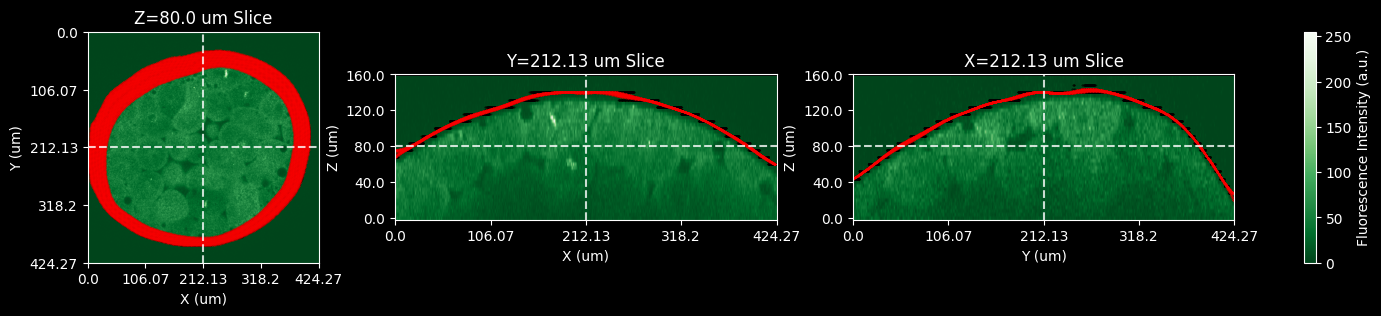

>> Plotting slices...


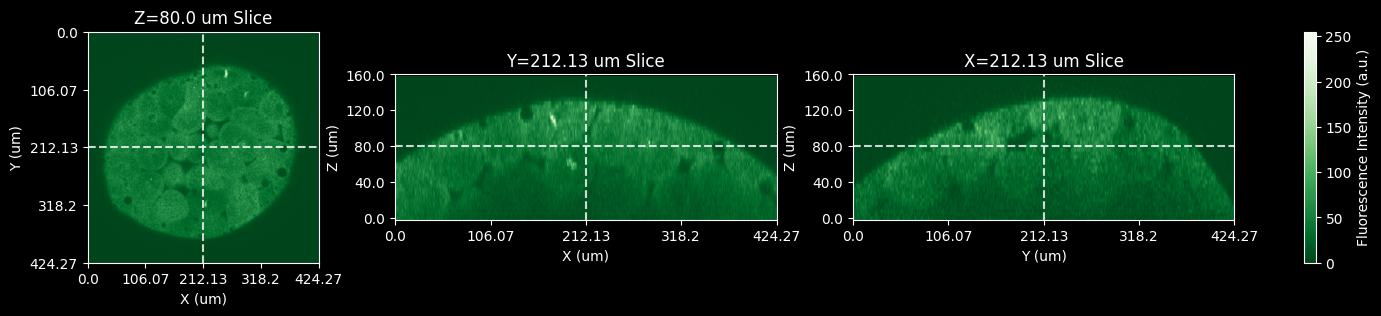

In [18]:
# ==== Smooth Mesh(es) ====
smooth_factor = 0.001
smooth_iterations = 200
full_mesh_smooth = analysis.taubin_smooth_mesh(mesh=full_mesh, n_iter=smooth_iterations, pass_band=smooth_factor)
inner_mesh_smooth = analysis.taubin_smooth_mesh(mesh=inner_mesh, n_iter=smooth_iterations, pass_band=smooth_factor)
outer_mesh_smooth = analysis.taubin_smooth_mesh(mesh=outer_mesh, n_iter=smooth_iterations, pass_band=smooth_factor)

# ==== Sub-Sample Mesh(es) ====
# full_mesh_smooth = analysis.subdivide_mesh(mesh=full_mesh_smooth, max_edge=2)
# inner_mesh_smooth = analysis.subdivide_mesh(mesh=inner_mesh_smooth, max_edge=2)
# outer_mesh_smooth = analysis.subdivide_mesh(mesh=outer_mesh_smooth, max_edge=2)

# ==== Save Mesh(es) ====
datahandler.save_mesh(full_mesh_smooth, os.path.join(resdata_dir, "full_mesh_smooth.ply"))
datahandler.save_mesh(inner_mesh_smooth, os.path.join(resdata_dir, "inner_mesh_smooth.ply"))
datahandler.save_mesh(outer_mesh_smooth, os.path.join(resdata_dir, "outer_mesh_smooth.ply"))

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_smooth_full-mesh.png"), meshes=[full_mesh, full_mesh_smooth],
                 mesh_colors=["black", "purple"])
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_smooth_inner-mesh.png"),
                 meshes=[inner_mesh, inner_mesh_smooth], mesh_colors=["black", "red"])
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_smooth_outer-mesh.png"),
                 meshes=[outer_mesh, outer_mesh_smooth], mesh_colors=["black", "blue"])

In [20]:
# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[inner_mesh, inner_mesh_smooth], mesh_colors=["grey", "red"],
#                   mesh_titles=["Inner Mesh", "Smooth Inner Mesh"], mesh_opacities=[0.3, 0.3])
# visuals.view_mesh(mesh_list=[full_mesh, full_mesh_smooth], mesh_colors=["grey", "red"],
#                   mesh_titles=["Full Mesh", "Smooth Full Mesh"], mesh_opacities=[0.3, 0.3], img=img_raw,
#                   scale=img_scale)

visuals.view_mesh(mesh_list=[inner_mesh_smooth, outer_mesh_smooth], mesh_colors=["red", "blue"],
                  mesh_titles=["Smooth Inner Mesh", "Smooth Outer Mesh"], mesh_opacities=[0.3, 0.3], img=img_raw,
                  scale=img_scale)

# visuals.view_mesh(mesh_list=[full_mesh_smooth], mesh_colors=["white"],
#                   mesh_titles=["Smooth Full Mesh"], mesh_opacities=[1.0], vec_freq=5,
#                   img=img_raw, img_opacity=0.5, scale=img_scale)

>> Rendering mesh...


## |4| EMBL Sphere Fit

>> Saved /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/sphere_fit.csv !
>> Identifying surfaces using mask...
Num of sphere vertices: 606273
>> Plotting slices...


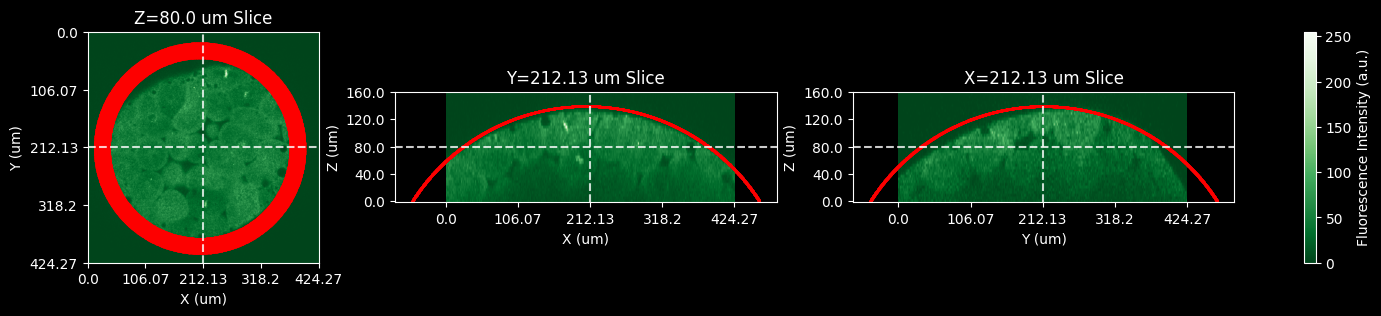

In [21]:
mesh_to_fit = inner_mesh_smooth.copy()
# mesh_to_fit = datahandler.load_mesh(os.path.join(resdata_dir, "inner_mesh_smooth.ply"), recalc_normals=True)
# ==== Fit Sphere ====
sphere_params = analysis.fit_sphere(points=mesh_to_fit.vertices)
sphere_x0, sphere_y0, sphere_z0, sphere_radius = sphere_params
sphere_mesh = trimesh.creation.icosphere(radius=sphere_radius, subdivisions=9)
sphere_mesh.vertices += [sphere_x0, sphere_y0, sphere_z0]
datahandler.save_array(np.array(sphere_params)[:, np.newaxis].T, "sphere_fit", header="x,y,z,radius",
                       folderpath=resdata_dir)
# ==== Crop Sphere ====
zmax, zmin = sphere_mesh.vertices[:, 0].max(), sphere_mesh.vertices[:, 0].min()
sphere_crop_mask = sphere_mesh.vertices[:, 0] > (zmax - zmin) / 1.3 + zmin
# sphere_crop_mask = sphere_mesh.vertices[:, 0] <= (zmax - zmin) / 2.8 + zmin
# sphere_crop_mask = np.ones_like(sphere_crop_mask)
sphere_mesh_cropped = analysis.sel_submesh(mesh=sphere_mesh, mask=sphere_crop_mask)
# sphere_mesh_cropped = analysis.subdivide_mesh(sphere_mesh_cropped, 1.5)
print(f"Num of sphere vertices: {sphere_mesh_cropped.vertices.shape[0]}")

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_raw_sphere-fit.png"), cmap="Greens_r",
                 meshes=[sphere_mesh_cropped], mesh_alpha=1.0)

In [22]:
# ==== 3D Render Mesh(es) ====
visuals.view_mesh([sphere_mesh], img=img_raw, scale=img_scale)

>> Rendering mesh...


## |5| Save Sampling Mesh

>> Saving mesh to /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/sampling_mesh.ply...
>> Plotting slices...


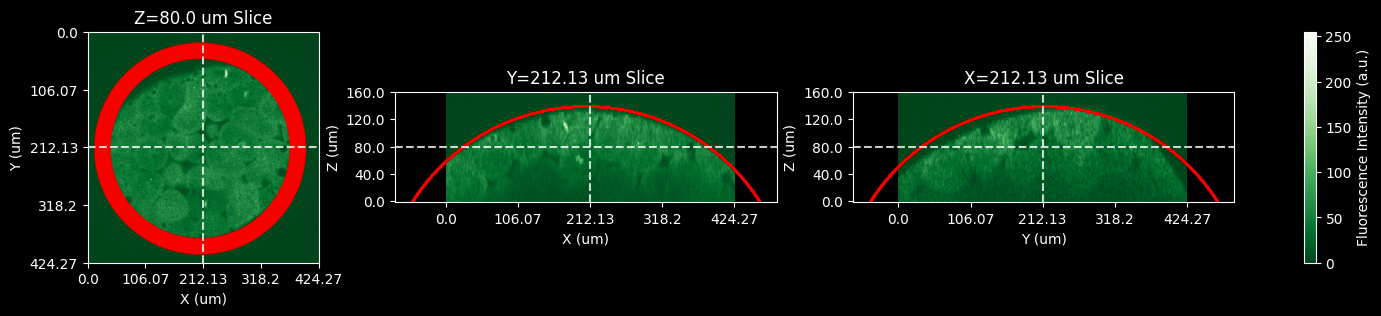

Number of sampling points: 606273 !


In [32]:
# ==== Select Sampling Mesh ====
# sampl_mesh = full_mesh_smooth.copy()
sampl_mesh = sphere_mesh_cropped.copy()
# sampl_mesh = inner_mesh_smooth.copy()

# ==== Save Sampling Mesh ====
datahandler.save_mesh(sampl_mesh, os.path.join(resdata_dir, "sampling_mesh.ply"))

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit,
                 savefig=os.path.join(resfig_dir, "sliced_raw_sampling-mesh.png"), meshes=[sampl_mesh])
print(f"Number of sampling points: {len(sampl_mesh.vertices)} !")

# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[sampl_mesh], mesh_titles=["Mesh"], mesh_colors=["white"], mesh_opacities=[0.4],
#                   img=img_raw, scale=img_scale, vec_freq=100, hide_vectors=True, vec_length=20)

# -- Load Mesh --

>> Loading mesh /Users/andreadi/Library/CloudStorage/OneDrive-UniversitédeGenève/Academic/Data/4_collaborations/magdalena_embl/time-lapse/CTL_TG_His_lyn_E25_20230926_block1_New-01And-2To7-TP10To13/data/sampling_mesh.ply...
>> Recomputing normals ...
Number of sampling vertices: 274156 !
>> Plotting slices...


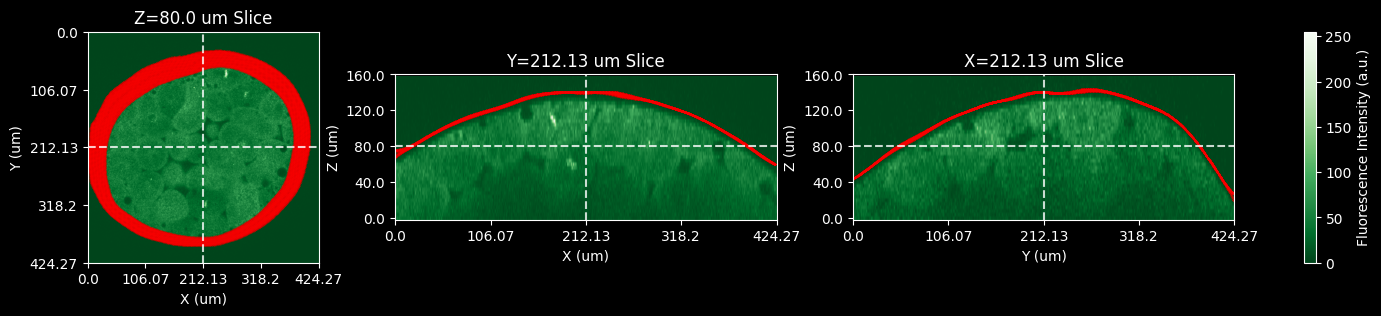

>> Rendering mesh...


In [31]:
# ==== Load Sampling Mesh ====
sampl_mesh = datahandler.load_mesh(os.path.join(resdata_dir, "sampling_mesh.ply"), recalc_normals=True, clean=True)
print(f"Number of sampling vertices: {len(sampl_mesh.vertices)} !")
# # sampl_mesh.show()

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, meshes=[sampl_mesh],
                 savefig=os.path.join(resfig_dir, "sliced_raw_sampling-mesh.png"))

# ==== Plot Half Max Projection Views ====
# visuals.plot_maxproj_pts(verts=sampl_mesh.vertices, unit=img_unit, cmap="Greys",
#                          savefig=os.path.join(resfig_dir, "maxproj_sampling-mesh.png"), hexsize=100, figsize=(12, 5))
# ==== 3D Render Mesh(es) ====
# visuals.view_mesh(mesh_list=[sampl_mesh], mesh_titles=["Mesh"], mesh_colors=["white"], mesh_opacities=[0.4],
#                   img=img_raw, scale=img_scale, vec_freq=400, hide_vectors=True, vec_length=20)
# visuals.view_mesh(mesh_list=[sampl_mesh], mesh_titles=["Mesh"], mesh_colors=["white"], mesh_opacities=[0.4],
#                   img=img_raw, scale=img_scale, vec_freq=100, hide_vectors=False, vec_length=20)

# Mesh Analysis

### |0| Choose Two Meshes for Analysis

In [ ]:
# ==== Select Mesh(es) ====
mesh_1 = datahandler.load_mesh(os.path.join(resdata_dir, "inner_mesh_smooth.ply"), recalc_normals=False)
mesh_2 = datahandler.load_mesh(os.path.join(resdata_dir, "outer_mesh_smooth.ply"), recalc_normals=False)

# ==== Plot Image Slices with Mesh Overlay ====
visuals.plot_img(img=img_raw, scale=img_scale, unit=img_unit, meshes=[mesh_1, mesh_2],
                 mesh_colors=["red", "blue"])

# ==== 3D Render Mesh(es) ====
visuals.view_mesh(mesh_list=[mesh_1, mesh_2],
                  mesh_colors=["Green", "Red"],
                  mesh_titles=["MESH 1", "MESH 2"])

## |1| Sampling Density Estimate

In [ ]:
# ==== Calculate Sampling Density Estimate of Mesh ====
density_crop_range = None  #[0,2]
densities, densities_idxs = analysis.density_estimate(mesh_1, k=100, debug=True, crop_range=density_crop_range)

# ==== Save Sampling Density Estimate of Mesh ====
datahandler.save_array(densities, "densities", header=f"density (1/{img_unit}^2)", folderpath=resdata_dir)
datahandler.save_array(densities_idxs, "densities_idxs", header=f"idx", folderpath=resdata_dir)

# ==== Plot Sampling Density Estimate of Mesh ====
visuals.plot_hist(densities, title=f"Densities AVG = {densities.mean():.2e} 1/{img_unit}^2",
                  savefig=os.path.join(resfig_dir, "density_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_1.vertices[densities_idxs], unit=img_unit, cmap="Spectral",
                         colors=densities, cmap_label=f"Density Estimate 1/{img_unit}^2",
                         hexsize=100, savefig=os.path.join(resfig_dir, "maxproj_sampling-mesh.png"), figsize=(12, 5))

In [ ]:
# ==== 3D Render Result ====
# visuals.view_colored_verts(mesh_1.vertices[densities_idxs],
#                            colors=visuals.color_scalar(analysis.normalise_range(densities), cmap="Spectral"))

## |2| Inter-Mesh Distance/Thickness

In [ ]:
# ==== Calculate Inter-Mesh Distance ====
thickness_crop_range = [0, 100]
# thickness_crop_range = None
thickness_sampl_number = 5000
dist_vals, dist_idxs = analysis.inter_dist_mesh(mesh_1=mesh_1, mesh_2=mesh_2, num_sample=thickness_sampl_number,
                                                crop_range=thickness_crop_range, debug=True)

# ==== Save Inter-Mesh Distance ====
datahandler.save_array(dist_vals, "thickness", header=f"dist ({img_unit})", folderpath=resdata_dir)
datahandler.save_array(dist_idxs, "thickness_idxs", header=f"idx", folderpath=resdata_dir)

# ==== Plot Inter-Mesh Distance ====
visuals.plot_hist(array=dist_vals, title=f"Thickness AVG = {dist_vals.mean():.2e} {img_unit}",
                  xlim=thickness_crop_range,
                  savefig=os.path.join(resfig_dir, "thickness_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_1.vertices[dist_idxs], unit=img_unit, colors=dist_vals, cmap="Spectral",
                         hexsize=100, cmap_label=f"Thickness ({img_unit})",
                         savefig=os.path.join(resfig_dir, "thickness.png"), figsize=(12, 5))

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4), sharey=True)
ax[0].scatter(mesh_1.vertices[dist_idxs][:, 0], dist_vals, marker="x")
ax[1].scatter(mesh_1.vertices[dist_idxs][:, 1], dist_vals, marker="x")
ax[2].scatter(mesh_1.vertices[dist_idxs][:, 2], dist_vals, marker="x")
ax[0].set_xlabel(f"x ({img_unit})")
ax[1].set_xlabel(f"y ({img_unit})")
ax[2].set_xlabel(f"z ({img_unit})")
ax[0].set_ylabel(f"Thickness ({img_unit})")
plt.show()

In [ ]:
# ==== 3D Render Result ====
# visuals.view_mesh_and_verts(mesh_list=[mesh_1, mesh_2], mesh_colors=["white", "white"],
#                             verts=mesh_1.vertices[dist_idxs],
#                             verts_colors=visuals.color_scalar(analysis.normalise_range(dist_vals), cmap="Spectral"),
#                             use_orig_color=True, verts_size=3)

## |4| Gaussian & Mean Curvature

In [ ]:
mesh_curvature = sampl_mesh.copy()
# mesh_curvature.vertex_normals = mesh_curvature.vertex_normals * -1

In [ ]:
# ==== Define Range of Gauss & Mean Curvature ====
gauss_exp = 1 / (np.ptp(mesh_curvature.vertices, axis=0).mean() / 2) ** 2
mean_exp = 1 / (np.ptp(mesh_curvature.vertices, axis=0).mean() / 2)
print(f"Gauss should be around {gauss_exp:.2e} (1/{img_unit}^2), "
      f"Mean should be around {mean_exp:.2e} (1/{img_unit})")
gauss_order_min, gauss_order_max = round(np.log10(gauss_exp)) - 1, round(np.log10(gauss_exp)) + 1
mean_order_min, mean_order_max = round(np.log10(mean_exp)) - 1, round(np.log10(mean_exp)) + 1
gauss_crop_range = [0.5 * 10 ** gauss_order_min, 10 ** gauss_order_max]
mean_crop_range = [0.5 * 10 ** mean_order_min, 10 ** mean_order_max]

gauss_crop_range, mean_crop_range = None, None

curvature_num_samples = 10000

curvature_filter_boundary = False
curvature_filter_boundary_factor = 0.0  # exclude strength between 0 (max) and 1 (no exclusion)

# ==== Calculate Gauss & Mean Curvature ====
curvature_results = analysis.curvature_by_srf_fit(mesh_curvature, num_sample=curvature_num_samples, k=20,
                                                  debug=True, filter_boundary=curvature_filter_boundary,
                                                  boundary_excl_factor=curvature_filter_boundary_factor,
                                                  gauss_crop_range=gauss_crop_range, mean_crop_range=mean_crop_range)

C_gauss, C_mean, C_gauss_idxs, C_mean_idxs = curvature_results

# ==== Save Gauss & Mean Curvature ====
datahandler.save_array(C_gauss, "gauss_curv", header=f"gauss (1/{img_unit}^2)", folderpath=resdata_dir)
datahandler.save_array(C_gauss_idxs, "gauss_curv_idxs", header=f"idx", folderpath=resdata_dir)
datahandler.save_array(C_mean, "mean_curv", header=f"mean (1/{img_unit})", folderpath=resdata_dir)
datahandler.save_array(C_mean_idxs, "mean_curv_idxs", header=f"idx", folderpath=resdata_dir)

# ==== Plot Gauss & Mean Curvature ====
visuals.plot_hist(C_gauss, title=f"Gauss AVG = {C_gauss.mean():.2e} (1/{img_unit}^2)",
                  savefig=os.path.join(resfig_dir, "gauss_hist.png"))
visuals.plot_hist(C_mean, title=f"Mean AVG = {C_mean.mean():.2e} (1/{img_unit})",
                  savefig=os.path.join(resfig_dir, "mean_hist.png"))
visuals.plot_maxproj_pts(verts=mesh_curvature.vertices[C_gauss_idxs], unit=img_unit, colors=C_gauss, cmap="Spectral",
                         hexsize=100, cmap_label=f"Gaussian Curvature (1/{img_unit}^2)",
                         savefig=os.path.join(resfig_dir, "gauss_curv.png"))
visuals.plot_maxproj_pts(verts=mesh_curvature.vertices[C_mean_idxs], unit=img_unit, colors=C_mean, cmap="Spectral",
                         hexsize=100, cmap_label=f"Mean Curvature (1/{img_unit})",
                         savefig=os.path.join(resfig_dir, "mean_curv.png"))

In [ ]:
# ==== 3D Render Result ====
visuals.view_mesh_and_verts(mesh_list=[mesh_curvature], verts=mesh_curvature.vertices[C_gauss_idxs],
                            verts_colors=visuals.color_scalar(analysis.normalise_range(C_gauss),
                                                              manual_vminmax=gauss_crop_range), verts_size=2,
                            use_orig_color=True, mesh_colors="white")
# visuals.view_mesh_and_verts(mesh_list=[mesh_curvature], verts=mesh_curvature.vertices[C_mean_idxs],
#                             verts_colors=visuals.color_scalar(analysis.normalise_range(C_mean)), verts_size=3,
#                             use_orig_color=True, mesh_colors="white")

# Projection onto Mesh

## |1| Find Min & Max Distance

>> Projecting max image intensities on verts using linear interpolation method...
Range: MIN = 0.0um, MAX = 40.0um, NUM = 20


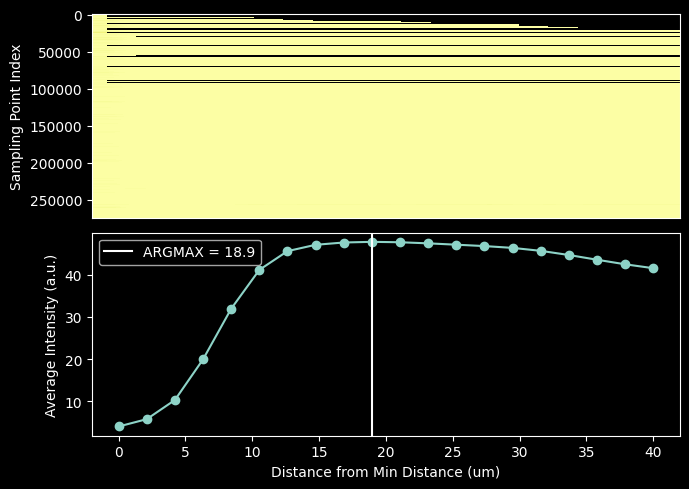

In [29]:
# ==== Define Projection Range ====
dist_min = 0.0
dist_max = 40.0
dist_num = 20

# ==== Specify Custom Minimum ====
dist_min_custom = None
# dist_min_custom = np.linspace(0, 5, sampl_mesh.vertices.shape[0])

# ==== Project onto Mesh ====
proj_broad = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, unit=img_unit, min_dist_per_vert=dist_min_custom,
                                scale=img_scale, min_dist=dist_min,
                                max_dist=dist_max, num_dist=dist_num, mode="max",
                                show_proj=True, savefig=os.path.join(resfig_dir, "distgraph_broad-scan.png"),
                                normalise=False)

# ==== Plot Projected Result ====
# visuals.plot_maxproj_pts(verts=sampl_mesh.vertices, colors=proj_broad, cmap="Greens", hexsize=200,
#                          savefig=os.path.join(resfig_dir, "maxproj_broad-scan.png"), unit=img_unit, figsize=(18, 8))

In [30]:
# ==== 3D Render Projected Result ====
visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_broad),
                                                                            cmap="Greens_r"),
                          mesh_blending="opaque")  #, img=img_raw, scale=img_scale)

>> Rendering colored mesh...


In [ ]:
# ==== Plot Mercator Projection ====
mercator_x, mercator_y = analysis.mercator_project(
    pts=sampl_mesh.vertices)  #, ref_point=[sphere_x0, sphere_y0, sphere_z0],rotate=[90, 0, 90])
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, aspect="equal",
                              intensities=proj_broad, figsize=(14, 8), ptview=False, hexgridsize=50,
                              savefig=os.path.join(resfig_dir, "distgraph_broad-scan_mercator.png"))

In [ ]:
# min_proj_dist = 2.0
# max_proj_dist = 15.0
# slice_proj = float(np.max(img_scale))
# num_proj_samples = int(np.max(img_scale) / np.min(img_scale))
# proj_mode = "max"
# min_all = np.arange(min_proj_dist, max_proj_dist, slice_proj)
# max_all = min_all + slice_proj
# mask = max_all <= max_proj_dist
# min_all, max_all = min_all[mask], max_all[mask]
# proj_tasks = np.column_stack((min_all, max_all, np.full_like(min_all, num_proj_samples)))
#
# all_projections = np.empty((len(proj_tasks), len(sampl_mesh.vertices)))
# for i, proj_task in enumerate(proj_tasks):
#     dist_min, dist_max, dist_num = proj_task
#     all_projections[i] = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, unit=img_unit, min_dist_per_vert=None,
#                                             scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num,
#                                             mode=proj_mode, show_proj=False, savefig="", normalise=False)
# print("=======")
# print(f"Projected {len(all_projections)} layers !!")
#
#
# proj_xcords, proj_ycords = analysis.mercator_project(pts=sampl_mesh.vertices)
# radial_stack = analysis.create_zstack(values=all_projections, phi_coords=proj_xcords, ycords=proj_ycords, grid_n=img_dim[1])
# visuals.plot_matrix(radial_stack[0], figsize=(14, 8), origin="upper")
# datahandler.save_tiff(radial_stack, filepath=os.path.join(resfig_dir, "radial-stack.tiff"))

### |1.1| EMBL Spherical Projection

In [ ]:
sphere_x0, sphere_y0, sphere_z0, sphere_radius = datahandler.load_array("sphere_fit", folderpath=resdata_dir)[0, :]
print(f"sphere_x0 = {sphere_x0} {img_unit}")
print(f"sphere_y0 = {sphere_y0} {img_unit}")
print(f"sphere_z0 = {sphere_z0} {img_unit}")
print(f"sphere_radius = {sphere_radius} {img_unit}")

In [ ]:
min_proj_dist = 0.0
max_proj_dist = 8.0
slice_proj = 4.0
num_proj_samples = int(np.max(img_scale) / np.min(img_scale))
proj_mode = "mean"
min_all = np.arange(min_proj_dist, max_proj_dist, slice_proj)
max_all = min_all + slice_proj
mask = max_all <= max_proj_dist
min_all, max_all = min_all[mask], max_all[mask]
proj_tasks = np.stack([
    min_all,
    max_all,
    np.full(min_all.shape, num_proj_samples)
], axis=1)

proj_radii = sphere_radius - (min_all + 0.5 * slice_proj)
print(f">> Projecting at radii {proj_radii} {img_unit} ...")
# Flip direction of projection for going "inwards"
proj_tasks[:, :2] *= -1

all_projections = np.empty((len(proj_tasks), len(sampl_mesh.vertices)))
for i, proj_task in enumerate(proj_tasks):
    dist_min, dist_max, dist_num = proj_task
    all_projections[i] = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, unit=img_unit, min_dist_per_vert=None,
                                            scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num,
                                            mode=proj_mode, show_proj=False, savefig="", normalise=False)
print("=======")
print(f"Projected {len(all_projections)} layers !!")

In [ ]:
proj_xcords, proj_ycords = analysis.mercator_project(pts=sampl_mesh.vertices,
                                                     ref_point=[sphere_x0, sphere_y0, sphere_z0])
radial_projection = analysis.create_radial_stack(values=all_projections,
                                                 phi_coords=proj_xcords,
                                                 theta_cords=proj_ycords,
                                                 grid_n=np.mean(img_dim[1:]), projection_radii=proj_radii)
radial_stack, stack_cords = radial_projection
mid_radial_stack_i = radial_stack.shape[0] // 2

visuals.plot_matrix(radial_stack[mid_radial_stack_i], figsize=(14, 8), origin="upper",
                    title=f"R = {proj_radii[mid_radial_stack_i]:,.2f} {img_unit}",
                    savefig=os.path.join(resfig_dir, f"radial-stack_{mid_radial_stack_i}.png"),
                    unit="px", colorbar=True, cmap="inferno")

np.savez_compressed(os.path.join(resdata_dir, "radial_projection.npz"), radial_stack=radial_stack,
                    stack_cords=stack_cords)

In [ ]:
radial_stack = np.load(os.path.join(resdata_dir, "radial_projection.npz"))["radial_stack"]
stack_cords = np.load(os.path.join(resdata_dir, "radial_projection.npz"))["stack_cords"]

datahandler.save_tiff(radial_stack, filepath=os.path.join(resfig_dir, "radial-stack.tiff"))

In [ ]:
# stack_coords_phi = stack_cords[0, ..., 0]
# visuals.plot_matrix(stack_coords_phi, origin="upper", colorbar=True, cmap="coolwarm")
# stack_coords_theta = stack_cords[0, ..., 1]
# visuals.plot_matrix(stack_coords_theta, origin="upper", colorbar=True, cmap="coolwarm")
# stack_coords_radii = stack_cords[:, 0, 0, 2]
# plt.figure()
# plt.hexbin(proj_ycords, proj_xcords, all_projections[0], gridsize=100)
# plt.gca().invert_yaxis()
# plt.gca().invert_xaxis()
# plt.show()

In [ ]:
# # ==== Experimental: Mercator Projection relative to Sphere Fit ====
# sphere_params_load = datahandler.load_array("sphere_fit", folderpath=resdata_dir)
# sphere_x0, sphere_y0, sphere_z0, sphere_radius = sphere_params_load[0, :]
# mercator_x, mercator_y = analysis.mercator_project(
#     pts=sampl_mesh.vertices, ref_point=[sphere_x0, sphere_y0, sphere_z0])
# visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, cmap="Greens_r",invert_y_axis=True,
#                               intensities=proj_broad, figsize=(14, 8), ptview=True, aspect="equal",
#                               savefig=os.path.join(resfig_dir, "distgraph_broad-scan_mercator.png"), ptsize=0.1)
# # ==== Experimental: Different Angle Mercator Projection relative to Sphere Fit ====
# # rotation_angles = [[0, 0, 0],
# #                    [np.pi / 4, 0, 0],
# #                    [np.pi / 2, 0, 0],
# #                    [np.pi / 2, 0, np.pi / 2]]
# # for rot_angles in rotation_angles:
# #     print(f"Rotation angles: {np.degrees(rot_angles)}")
# #     mercator_x, mercator_y = analysis.mercator_project(
# #         pts=sampl_mesh.vertices, rotate=rot_angles, ref_point=[sphere_x0, sphere_y0, sphere_z0])
# #     visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=proj_broad,
# #                                   aspect="equal", ptview=True, figsize=(14, 8))

## |2| Check Multi-Layering

In [ ]:
# ==== Define Projection Range and Intermediate Value ====
dist_middle = dist_min + (dist_max - dist_min) / 2
dist_middle = 10
dist_num = 50
print(f"Chosen Middle Distance {dist_middle} {img_unit}")
# ==== Specify Custom Minimum ====
dist_min_custom = None
# dist_min_custom = np.linspace(0, 5, sampl_mesh.vertices.shape[0])

# ==== Project onto Mesh ====
proj_full = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, min_dist_per_vert=dist_min_custom,
                               scale=img_scale, min_dist=dist_min, max_dist=dist_max, num_dist=dist_num, mode="max",
                               show_proj=False, return_full=True, unit=img_unit, normalise=False)

# ==== Plot Projected Result ====
distances, dist_points, radial_intensities = proj_full
verts_distcolor, distcolor, distcmap = visuals.colour_dist(distances=distances, middle_val=dist_middle,
                                                           radial_points=dist_points, mesh=sampl_mesh,
                                                           radial_intensities=analysis.normalise_range(
                                                               radial_intensities), cut_z=False)
visuals.plot_maxproj_pts(verts=verts_distcolor, colors=distcolor, unit=img_unit, cmap=distcmap, hexsize=300,
                         savefig=os.path.join(resfig_dir, "maxproj_multi-layer.png"))

In [ ]:
# ==== Plot Mercator Projection ====
mercator_x, mercator_y = analysis.mercator_project(
    pts=sampl_mesh.vertices)  #,ref_point=[sphere_x0, sphere_y0, sphere_z0])
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=distcolor, ptview=True,
                              figsize=(14, 8), cmap=distcmap,
                              savefig=os.path.join(resfig_dir, "multi-layer_mercator.png"))

In [ ]:
# ==== 3D Render Projected Result ====
# visuals.view_verts(verts=verts_distcolor, colors=distcolor, blending="opaque", opacity=0.6, point_size=1)
visuals.view_colored_mesh(mesh=sampl_mesh, color_override=distcolor)  #, img=img_raw, scale=img_scale)

In [ ]:
# ==== Plot Mercator Projections ====
rotation_angles = [[0, 0, 0],
                   [np.pi / 4, 0, 0],
                   [np.pi / 2, 0, 0],
                   [np.pi / 2, 0, np.pi / 2]]
for rot_angles in rotation_angles:
    print(f"Rotation angles: {np.degrees(rot_angles)}")
    mercator_x, mercator_y = analysis.mercator_project(
        pts=sampl_mesh.vertices, rotate=rot_angles)
    visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=distcolor, ptview=True,
                                  figsize=(5, 5), cmap=distcmap)

## |3| Isolate single layer

In [ ]:
# ==== Choose Projection Mode: full / inner / outer ====
layer_label = "inner"

try:
    dist_middle
except:
    dist_middle = dist_min + (dist_max - dist_min) / 2

# ==== Specify Custom Minimum ====
dist_min_custom = None
# dist_min_custom = np.linspace(0, 5, sampl_mesh.vertices.shape[0])

resdata_dir_layer = os.path.join(resdata_dir, layer_label)
resfig_dir_layer = os.path.join(resfig_dir, layer_label)
if not os.path.exists(resdata_dir_layer):
    os.makedirs(resdata_dir_layer)
if not os.path.exists(resfig_dir_layer):
    os.makedirs(resfig_dir_layer)

# ==== Save Sampling Vertices and Normals ====
datahandler.save_array(sampl_mesh.vertices, "verts", header="x,y,z", folderpath=resdata_dir_layer)
datahandler.save_array(sampl_mesh.vertex_normals, "normals", header="nx,ny,nz", folderpath=resdata_dir_layer)

if layer_label == "inner":
    min_radial_dist = dist_min
    max_radial_dist = dist_middle
elif layer_label == "outer":
    min_radial_dist = dist_middle
    max_radial_dist = dist_max
elif layer_label == "full":
    min_radial_dist = dist_min
    max_radial_dist = dist_max
else:
    min_radial_dist = dist_min
    max_radial_dist = dist_max

num_radial_dist = 30

# ==== Project onto Mesh ====
proj_layer = analysis.proj2mesh(img=img_raw, mesh=sampl_mesh, min_dist_per_vert=dist_min_custom,
                                scale=img_scale, min_dist=min_radial_dist, max_dist=max_radial_dist,
                                num_dist=num_radial_dist, mode="max", show_proj=True,
                                savefig=os.path.join(resfig_dir_layer, f"distgraph.png"), unit=img_unit,
                                normalise=False)

# ==== Save Projection ====
datahandler.save_array(proj_layer, "intensities", header="I", folderpath=resdata_dir_layer)

# ==== Plot Projected Result ====
mercator_x, mercator_y = analysis.mercator_project(pts=sampl_mesh.vertices)
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=proj_layer, hexgridsize=400,
                              savefig=os.path.join(resfig_dir_layer, "mercator.png"))

In [ ]:
# ==== 3D Render Projected Result ====
# visuals.view_colored_verts(verts=sampl_mesh.vertices, colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                            scale=img_scale,img=None, ptsize=2)
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
#                                                                             cmap="Greens_r"))  #, img=img_raw, scale=img_scale)

# -- Load Layer --

In [ ]:
# ==== Load Projected Result: full / inner / outer ====
layer_label = "inner"
resdata_dir_layer = os.path.join(resdata_dir, layer_label)
resfig_dir_layer = os.path.join(resfig_dir, layer_label)
proj_layer = datahandler.load_array("intensities", folderpath=resdata_dir_layer)
# proj_layer = analysis.normalise_range(proj_layer)

# ==== Plot Projected Result ====
visuals.plot_hist(proj_layer, title="Intensities (a.u.)")
mercator_x, mercator_y = analysis.mercator_project(pts=sampl_mesh.vertices)
visuals.plot_mercator_project(mercator_x=mercator_x, mercator_y=mercator_y, intensities=proj_layer, hexgridsize=400)

In [ ]:
# ==== 3D Render Projected Result ====
# visuals.view_colored_verts(verts=sampl_mesh.vertices,
#                            colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="inferno"),
#                            scale=img_scale, img=None, ptsize=0.7)
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
#                                                                             cmap="Greens_r"))  #, img=img_raw, scale=img_scale)

# -- Nematic Extraction & Analysis --

## |1| 2D Slice

### |1.1| Directors + S order

In [ ]:
# ==== Choose Slices for Analysis ====
sel_slices = np.arange(img_raw.shape[0])
sel_slices = [img_dim[0] // 2]
mask_thresh_val = 0.8 * np.min(analysis.yen_thresh(img_raw[sel_slices]))
img_selected = img_raw[img_dim[0] // 2].copy()

# ==== Saving Parameters  ====
figsize = (4, 4)
resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
datahandler.create_dir(resfig_dir_2dsliced)
datahandler.create_dir(resdata_dir_2dsliced)

# ==== Analysis Parameters ====
boxsize = 2 * 32
k = 5 ** 2
results_2d_slice = []
# ==== Enable Plotting ====
plot_figs = True

for i in sel_slices:
    print(f">> Analysing Z slice {i}")
    img_selected = img_raw[i].copy()
    # ==== 2D Orientation Analysis ====
    orient2d_results = analysis.orient2d(img=img_selected, boxsize=boxsize, thresh_val=mask_thresh_val, num_neigh_nem=k,
                                         debug=False)
    theta_all_deg, theta_masked_rad, S_2d, n_avg_2d, X, Y, directors_2d = orient2d_results

    directors_2d[:, 0] *= img_scale[1]
    directors_2d[:, 1] *= img_scale[2]
    directors_2d[:, :2] = directors_2d[:, [1, 0]]
    directors_2d_avg_local = np.column_stack((directors_2d[:, :2], n_avg_2d))
    results_2d_slice.append([i, np.nanmean(theta_all_deg), np.nanmean(S_2d)])
    interval = 500
    directors_2d, directors_2d_avg_local, S_2d = directors_2d[::interval], directors_2d_avg_local[::interval], S_2d[
                                                                                                               ::interval]
    print(f"Found {len(directors_2d)} directors !")

    # ==== Save Directors and Order ====
    datahandler.save_array(directors_2d, f"directors_2d_z-{i}", header="x,y,vx,vy", folderpath=resdata_dir_2dsliced)
    datahandler.save_array(S_2d, f"S-order_2d_k-{k}_z-{i}", header="S", folderpath=resdata_dir_2dsliced)
    datahandler.save_array(directors_2d_avg_local, f"directors-avg_2d_k-{k}_z-{i}",
                           header="x,y,vx,vy",
                           folderpath=resdata_dir_2dsliced)
    if plot_figs:
        # ==== Plot Results ====
        savefig_i = os.path.join(resfig_dir_2dsliced, f"z-{i}.png")
        savefig_theta = os.path.join(resfig_dir_2dsliced, f"z-{i}_theta.png")
        savefig_i_dirs = os.path.join(resfig_dir_2dsliced, f"z-{i}_dirs")
        savefig_dirs_s = os.path.join(resfig_dir_2dsliced, f"z-{i}_dirs_s")
        savefig_theta_hist_polar = os.path.join(resfig_dir_2dsliced, f"z_{i}_theta_hist.png")

        visuals.plot_matrix(img_selected, scale=img_scale, cmap='Greys_r', colorbar=True,
                            title='Intensity Profile', unit=img_unit,
                            figsize=figsize, savefig=savefig_i)
        visuals.plot_matrix(theta_all_deg, scale=img_scale, cmap='twilight', colorbar=True,
                            unit=img_unit,
                            title=f'Theta Angles for block {boxsize}x{boxsize}', figsize=figsize,
                            savefig=savefig_theta,
                            cmap_limits=[-90, 90])
        visuals.plot_polar_hist(angles_deg=theta_all_deg, savefig=savefig_theta_hist_polar, figsize=figsize)
        visuals.plot_hist(array=S_2d, title="order parameter $S$", figsize=figsize, savefig=savefig_dirs_s)

        # visuals.plot_matrix_vectors(Y, X, theta_masked_rad.T, img_selected, title="Intensity Profile + Directors",
        #                             figsize=(figsize[0] * 2, figsize[1]),
        #                             veclength=10, savefig=savefig_i_dirs, vec_colors=S_2d,
        #                             scale=img_scale,
        #                             cbar_matrix_label="Intensity Signal (a.u.)",
        #                             cbar_vector_label="order parameter $S$")

results_2d_slice = np.array(results_2d_slice)

### -- Load Segmentation Results --

In [ ]:
z_sel = img_dim[0] // 2

resfig_dir_2dsliced = os.path.join(resfig_dir, "2d-sliced_analysis")
resdata_dir_2dsliced = os.path.join(resdata_dir, "2d-sliced_analysis")
datahandler.create_dir(resfig_dir_2dsliced)
datahandler.create_dir(resdata_dir_2dsliced)
print(f"Z-slice selected: {z_sel}")
img_selected = img_raw[z_sel].copy()
seg_ellips_results = datahandler.load_array(name=f"2d-sliced_analysis/z-{z_sel}_seg-ellipses", folderpath=resdata_dir,
                                            return_df=True)
seg_ellips_results["aspect_ratio"] = seg_ellips_results["Ellipse.Radius1"] / seg_ellips_results["Ellipse.Radius2"]

# ==== [!!] ONLY DEBUG [!] ====
# seg_ellips_results["Ellipse.Orientation"] = np.ones(len(seg_ellips_results["Ellipse.Orientation"])) * 0  # !!!!!!
# seg_ellips_results["aspect_ratio"] = np.ones(len(seg_ellips_results["aspect_ratio"])) * 2
# seg_ellips_results["Ellipse.Orientation"] = np.random.uniform(-180, 180, size=len(seg_ellips_results["Ellipse.Orientation"]))
# ==== [!!] ONLY DEBUG [!] ====

seg_ellips_results["Ellipse.Orientation"] *= -1

seg_directors_2d = np.column_stack((seg_ellips_results["Ellipse.Center.X"], seg_ellips_results["Ellipse.Center.Y"],
                                    np.cos(np.radians(seg_ellips_results["Ellipse.Orientation"])),
                                    np.sin(np.radians(seg_ellips_results["Ellipse.Orientation"]))))

seg_directors_2d[:, :2] *= img_scale[1:]
directors_2d = seg_directors_2d.copy()
seg_ellips_results["shape_scalar"] = seg_ellips_results["aspect_ratio"] - 1
figsize = (22, 10)
visuals.plot_polar_hist(seg_ellips_results["Ellipse.Orientation"],
                        savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_thetas_polar-hist.png"))
visuals.plot_hist(seg_ellips_results["aspect_ratio"], title="Aspect Ratio",
                  savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_ar_hist.png"))
visuals.plot_matrix_vectors(x=seg_ellips_results["Ellipse.Center.X"], y=seg_ellips_results["Ellipse.Center.Y"],
                            angle_field=np.radians(seg_ellips_results["Ellipse.Orientation"]),
                            matrix=img_raw[0], veclength=15 * np.array(seg_ellips_results["aspect_ratio"]),
                            scale=img_scale, unit=img_unit, figsize=figsize,
                            vec_colors=seg_ellips_results["aspect_ratio"],
                            cbar_matrix_label="Intensity Signal (a.u.)",
                            cbar_vector_label="Aspect Ratio", title="Segmented Ellipse Long Axes",
                            savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_raw_ar.png"))

S_2d_seg_local, n_2d_seg_local = analysis.avg_2d_nem_tens(directors_2d, weights=None,
                                                          neigh_idxs=analysis.coord_search_neighbours(
                                                              directors_2d[:, :2], k=5))

visuals.plot_matrix_vectors(x=seg_ellips_results["Ellipse.Center.X"], y=seg_ellips_results["Ellipse.Center.Y"],
                            angle_field=np.radians(seg_ellips_results["Ellipse.Orientation"]),
                            matrix=img_raw[0], veclength=15 * np.array(seg_ellips_results["aspect_ratio"]),
                            scale=img_scale, unit=img_unit, figsize=figsize, vec_colors=S_2d_seg_local,
                            vec_cmap_limits=[0, 1], cbar_matrix_label="Intensity Signal (a.u.)",
                            cbar_vector_label="Local Nematic Order $S$", title="Local Nematic Order",
                            savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_raw_local_S.png"))
visuals.plot_hist(S_2d_seg_local, title="Local Nematic Order $S$",
                  savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_local_S_hist.png"))

nematic_weights = np.array(seg_ellips_results["shape_scalar"])
S_2d_seg_local, n_2d_seg_local = analysis.avg_2d_nem_tens(directors_2d,
                                                          analysis.coord_search_neighbours(directors_2d[:, :2], k=5),
                                                          weights=nematic_weights)
visuals.plot_matrix_vectors(x=seg_ellips_results["Ellipse.Center.X"], y=seg_ellips_results["Ellipse.Center.Y"],
                            angle_field=np.radians(seg_ellips_results["Ellipse.Orientation"]),
                            matrix=img_raw[0], veclength=15 * np.array(seg_ellips_results["aspect_ratio"]),
                            scale=img_scale, unit=img_unit, figsize=figsize, vec_colors=S_2d_seg_local,
                            cbar_matrix_label="Intensity Signal (a.u.)",
                            cbar_vector_label="Local Nematic Order $S$", title="Local Weighted Nematic Order",
                            savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_raw_local_S_weighted.png"))
visuals.plot_hist(S_2d_seg_local, title="Local Weighted Nematic Order $S$",
                  savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_seg_local_S_weighted_hist.png"))

### |1.2| Z-Dependence

In [ ]:
# ==== Plot Z-Dependance of 2D Orientation Analysis Results ====
# fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
# for ax, y, label in zip(axes, [1, 2], ["Mean Angle (°)", "Order Parameter"]):
#     ax.plot(results_2d_slice[:, 0] * img_scale[0], results_2d_slice[:, y], 'o-', label=label)
#     ax.set_ylabel(label)
#     ax.legend()
#     axes[1].set_xlabel(f"Z ({img_unit})")
# plt.savefig(os.path.join(resfig_dir, "2d_slice_nematic_order.png"))
# plt.show()

### |1.3| Find Axis of Elongation

In [ ]:
# ==== Img to be skeletonised ====
img_to_skeletonise = analysis.thresh_img(analysis.gaussian_blur(img_selected, 60, renorm=True), thresh=0.5)
img_to_skeletonise = analysis.fill_holes_img(img_to_skeletonise)
# img_to_skeletonise = analysis.gaussian_blur(img_to_skeletonise, 20, renorm=True)
visuals.plot_matrix(img_to_skeletonise, scale=img_scale, unit=img_unit, cmap='Greys_r')

In [ ]:
# ==== Find Medial Axis ====
medial_axis_scaled = analysis.find_medial_axis(img=img_to_skeletonise, scale=img_scale)
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d[:, :2], medial_axis_scaled)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_axis_scaled, pts=directors_2d[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal, unit=img_unit)
datahandler.save_array(medial_axis_scaled, "curve", header="x,y", folderpath=resdata_dir_2dsliced)

In [ ]:
# ==== Fit Spline to Medial Axis ====
spline_order_k = 1
spline_num_pts = 500
spline_smooth = 1.5
spline_sample_interv = 80
medial_start_u, medial_ed_u = -2.5, 2.5
medial_curve = analysis.spline_fit_curve(curve=medial_axis_scaled, order_k=spline_order_k, num_pts=spline_num_pts,
                                         smooth=spline_smooth, sample_interv=spline_sample_interv,
                                         start_u=medial_start_u, end_u=medial_end_u)
medial_curve = analysis.filter_curve_inside_shape(medial_curve, img_to_skeletonise, thresh=0.2,
                                                  scale=img_scale[1:])
print(f"Curve points inside shape = {len(medial_curve)}")
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d[:, :2], medial_curve)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_curve, pts=directors_2d[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal,
                               unit=img_unit, savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_ap-curve_proj.png"))
datahandler.save_array(medial_curve, "curve", header="x,y", folderpath=resdata_dir_2dsliced)

In [ ]:
# ==== Use PCA Axis instead ====
pca_axes, pca_center = analysis.find_pca_axes(img_to_skeletonise)
pca_axes[0] = [1, 0]
medial_curve = analysis.draw_pca_curve(pca_center=pca_center, pca_axes=pca_axes, dimensions=img_dim, scale=img_scale)
medial_curve = analysis.filter_curve_inside_shape(medial_curve, img_to_skeletonise, thresh=0.4,
                                                  scale=img_scale[1:])
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d[:, :2], medial_curve)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_curve, pts=directors_2d[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal, unit=img_unit,
                               savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_ap-curve_proj.png"))
datahandler.save_array(medial_curve, "curve", header="x,y", folderpath=resdata_dir_2dsliced)

### -- Load Curve of Elongation --

In [ ]:
# ==== Load PCA Axis instead ====
medial_curve = datahandler.load_array("curve", folderpath=resdata_dir_2dsliced)
# medial_curve = np.flip(medial_curve, axis=0)
s_parallel, s_orthogonal = analysis.proj2curve(directors_2d[:, :2], medial_curve)
visuals.plot_curve_projections(img=img_selected, scale=img_scale, curve=medial_curve, pts=directors_2d[:, :2],
                               s_parallel=s_parallel, s_orthogonal=s_orthogonal, unit=img_unit,
                               savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_ap-curve_proj.png"))

### |1.4| Accuracy of curve

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates, center_of_mass

curve = medial_curve.copy()
# Parameters
profile_half_width = 100  # how far to sample on each side of medial curve
num_samples = 2 * profile_half_width + 1
deltas = np.gradient(curve, axis=0)
tangents = deltas / np.linalg.norm(deltas, axis=1, keepdims=True)
normals = np.stack([-tangents[:, 1], tangents[:, 0]], axis=1)
curve_diffs = np.diff(curve, axis=0)
curve_lengths = np.linalg.norm(curve_diffs, axis=1)
arc_length = np.concatenate([[0], np.cumsum(curve_lengths)])

t = np.linspace(-profile_half_width, profile_half_width, num_samples)
offsets = normals[:, None, :] * t[None, :, None]
sample_points = curve[:, None, :] + offsets
coords = np.stack([sample_points[..., 1], sample_points[..., 0]], axis=0)
coords[0, :, :] /= img_scale[1]
coords[1, :, :] /= img_scale[2]
sampled_profiles = map_coordinates(img_to_skeletonise, coords, order=1, mode='nearest')
profile_sums = sampled_profiles.sum(axis=1, keepdims=True)
profile_sums[profile_sums == 0] = 1
positions = np.linspace(-profile_half_width, profile_half_width, num_samples)
center_of_mass_profiles = (sampled_profiles * positions[None, :]).sum(axis=1) / profile_sums[:, 0]

plt.figure(figsize=(10, 6))
plt.imshow(sampled_profiles.T, aspect='equal',
           extent=[arc_length[0], arc_length[-1], -profile_half_width, profile_half_width],
           origin='lower', cmap="jet")
plt.plot(arc_length, center_of_mass_profiles, color='red', label='Center of Mass')
plt.axhline(0, color='white', linestyle='--', alpha=0.7, label="Midline")
plt.xlabel(f'Distance along curve ({img_unit})')
plt.ylabel(f'Distance orthogonal to curve ({img_unit})')
plt.gca().invert_yaxis()
plt.legend()
plt.show()
plt.figure()
plt.title("Residual")
plt.plot(center_of_mass_profiles, "o-")
plt.show()
visuals.plot_hist(center_of_mass_profiles, title="Residual")


### |1.4| Average along binned A-P axes

In [ ]:
num_parallel_bins = 10
num_orthogonal_bins = 5
nematic_weights = np.array(seg_ellips_results["shape_scalar"])
ap_par_binned_idxs = analysis.bin_array_with_indices(s_parallel, num_parallel_bins)
ap_orth_binned_idxs = analysis.bin_array_with_indices(s_orthogonal, num_orthogonal_bins)
bin_avg_results = analysis.bin_directors(directors=directors_2d,
                                         s_parallel=s_parallel,
                                         s_orthogonal=s_orthogonal,
                                         ap_orth_binned_idxs=ap_orth_binned_idxs,
                                         ap_par_binned_idxs=ap_par_binned_idxs,
                                         curve=medial_curve,
                                         nematic_weights=nematic_weights)
parallel_results, orthogonal_results, nematic_results_weighted, nematic_results_unweighted = bin_avg_results
ap_par_binned_dirs, s_parallel_bin_centers, s_par_orthogonality_weighted, s_par_orthogonality_unweighted = parallel_results
ap_orth_binned_dirs, s_orthogonal_bin_centers, s_orth_orthogonality_weighted, s_orth_orthogonality_unweighted = orthogonal_results
ap_par_binned_S_2d_weighted, ap_par_binned_n_2d_weighted, ap_orth_binned_S_2d_weighted, ap_orth_binned_n_2d_weighted = nematic_results_weighted
ap_par_binned_S_2d_unweighted, ap_par_binned_n_2d_unweighted, ap_orth_binned_S_2d_unweighted, ap_orth_binned_n_2d_unweighted = nematic_results_unweighted
visuals.plot_director_bins(ap_par_binned_dirs=ap_par_binned_dirs, ap_orth_binned_dirs=ap_orth_binned_dirs,
                           ap_par_binned_idxs=ap_par_binned_idxs, ap_orth_binned_idxs=ap_orth_binned_idxs,
                           unit=img_unit, pt_size=50,
                           savefig=os.path.join(resfig_dir_2dsliced, f"z-{z_sel}_bins.png"))

binned_ap_res_name = f"z-{z_sel}_ap-binned_nematic.png"
visuals.plot_binned_ap_results_horizontal(img=img_selected, curve=medial_curve,
                                          s_parallel_bin_centers=s_parallel_bin_centers,
                                          scale=img_scale, unit=img_unit,
                                          s_orthogonal_bin_centers=s_orthogonal_bin_centers,
                                          ap_par_binned_s_2d_weighted=ap_par_binned_S_2d_weighted,
                                          ap_orth_binned_s_2d_weighted=ap_orth_binned_S_2d_weighted,
                                          ap_par_binned_s_2d_unweighted=ap_par_binned_S_2d_unweighted,
                                          ap_orth_binned_s_2d_unweighted=ap_orth_binned_S_2d_unweighted,
                                          s_par_orthogonality_weighted=s_par_orthogonality_weighted,
                                          s_orth_orthogonality_weighted=s_orth_orthogonality_weighted,
                                          s_par_orthogonality_unweighted=s_par_orthogonality_unweighted,
                                          s_orth_orthogonality_unweighted=s_orth_orthogonality_unweighted,
                                          savefig=os.path.join(resfig_dir_2dsliced, binned_ap_res_name))

## |2| 2D+ Curved Surface

### |2.1| Select and Define surface patches

In [ ]:
# ==== Pres-Select Vertices for 2D+ Orientation Analysis ====
idxs_sel = np.arange(sampl_mesh.vertices.shape[0])

# ==== Filter by Intensity Value ====
cutoff_min_intensity = 0.2 * np.max(proj_layer)
cutoff_max_intensity = 1.0 * np.max(proj_layer)
idxs_sel = idxs_sel[(proj_layer > cutoff_min_intensity) & (proj_layer < cutoff_max_intensity)]

# ==== Compute only points at Interval ====
compute_interval = 50
# idxs_sel = idxs_sel[::compute_interval]
idxs_sel = np.random.choice(idxs_sel, size=int(len(sampl_mesh.vertices) / compute_interval))

if len(idxs_sel) == 0:
    print("!! ERROR: No vertices were selected for analysis !!")

# ==== Search Nearest Neighbours ====
k = 800
idxs_neigh = analysis.coord_search_neighbours(verts=sampl_mesh.vertices, custom_probes=sampl_mesh.vertices[idxs_sel],
                                              k=k, n_process=8)

# ==== Filter Valid Surface Patches ====
idxs_neigh, valid_patch_idxs = analysis.filter_valid_patches(verts=sampl_mesh.vertices, idxs_neigh=idxs_neigh,
                                                             factor=0.1)
idxs_sel = idxs_sel[valid_patch_idxs]

# ==== Filter by Intensity Variation ====
cutoff_intensity_variance = 0.0

proj_layer_variance = np.var(proj_layer[idxs_neigh], axis=1)
visuals.plot_hist(proj_layer_variance, title="Intensity Variance per Patch")
filter_intens_var_mask = proj_layer_variance > cutoff_intensity_variance
idxs_sel = idxs_sel[filter_intens_var_mask]
idxs_neigh = idxs_neigh[filter_intens_var_mask]

# ==== Find Nearest Intensities ====
proj_layer_neigh = proj_layer[idxs_neigh]

# ==== Save Vertices for 2D+ Orientation Analysis ====
print(f"Num of directors to be calculated: {len(idxs_sel)} !")
datahandler.save_array(idxs_sel, "calcindeces", header="idx", folderpath=resdata_dir_layer)

# ==== Create the Tangential Bases ====
tan_cords, tan_x, tan_y = analysis.tan_proj(sampl_mesh.vertices[idxs_neigh], sampl_mesh.vertex_normals[idxs_sel])

# ==== Save the Tangential Bases ====
datahandler.save_array(tan_x, "tan_x", header="t1x,t1y,t1z", folderpath=resdata_dir_layer)
datahandler.save_array(tan_y, "tan_y", header="t2x,t2y,t2z", folderpath=resdata_dir_layer)

In [ ]:
# ==== 3D Render Vertices for 2D+ Orientation Analysis ====
visuals.view_colored_verts(verts=sampl_mesh.vertices[idxs_sel],
                           colors=visuals.color_scalar(proj_layer[idxs_sel], cmap="Greens_r"), scale=img_scale)

In [ ]:
# ==== 3D Render a Surface Patch ====
# visuals.view_neighbourhood(points=sampl_mesh.vertices, mesh_blending="translucent_no_depth", intensities=analysis.normalise_range(proj_layer),
#                            mesh_opacity=0.2, neighbours=sampl_mesh.vertices[idxs_neigh],
#                            sel_idx=np.random.choice(np.arange(idxs_sel.shape[0])), pt_size=1,
#                            neighbour_opacity=1.0, )

# ==== 3D Render all vertices to be calculated on ====
# all_calculated_mask = np.isin(np.arange(sampl_mesh.vertices.shape[0]), idxs_sel)
# all_calculated_color = ["red" if i else "grey" for i in all_calculated_mask]
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=all_calculated_color)  #, img=img_raw, scale=img_scale)

### |2.2| Extract Directors

In [ ]:
# ==== Tune Local Orientation Extraction Accuracy ====
grid_N = 30
box_size = grid_N // 3
debug_2dcurve_analysis = False
print(f">> Using local grid of NxN: {grid_N}...")
if debug_2dcurve_analysis:
    # ==== Create Single Grid ====
    debug_vert_idx = np.random.choice(np.arange(idxs_sel.shape[0]))
    print(f"Debugging index: {debug_vert_idx}")
    grid_x, grid_y, grid_z = analysis.tan_interp_batch(coords=tan_cords[[debug_vert_idx]],
                                                       intensities=proj_layer_neigh[[debug_vert_idx]],
                                                       grid_size=grid_N)
    debug_grid_x, debug_grid_y, debug_grid_z = grid_x[0], grid_y[0], grid_z[0]
    big_grid = np.vstack([grid.T for grid in grid_z])
else:
    # ==== Create Multi-Grid ====
    grid_x, grid_y, grid_z = analysis.tan_interp_batch(coords=tan_cords,
                                                       intensities=proj_layer_neigh,
                                                       grid_size=grid_N)
    big_grid = np.vstack([grid.T for grid in grid_z])
    debug_vert_idx, debug_grid_x, debug_grid_y, debug_grid_z = None, None, None, None

# ==== Extract Directors ====
directors_2dcurved = analysis.batch_2d_orientation(big_grid=big_grid, box_size=box_size,
                                                   vertices=sampl_mesh.vertices[idxs_sel],
                                                   tan_x=tan_x, tan_y=tan_y,
                                                   debug=debug_2dcurve_analysis, debug_idx=debug_vert_idx,
                                                   debug_grid_x=debug_grid_x, debug_grid_y=debug_grid_y,
                                                   debug_grid_z=debug_grid_z, tan_cords=tan_cords)

if not debug_2dcurve_analysis:
    # ==== Save Directors ====
    datahandler.save_array(directors_2dcurved, "directors_2dcurved", header="x,y,z,vx,vy,vz",
                           folderpath=resdata_dir_layer)

    # ==== Plot Directors ====
    visuals.plot_dir_field(directors=directors_2dcurved,
                           savefig=os.path.join(resfig_dir_layer, "directors_2dcurved.png"),
                           veclength=10)

In [ ]:
# ==== 3D Render Directors ====
veclength = 10
# visuals.view_3d_vector_field(vec_pos=directors_2dcurved[:, :3], vec_dir=directors_2dcurved[:, 3:], vec_colors="red",
#                              verts=sampl_mesh.vertices, verts_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                              edge_width=veclength / 6, length=veclength, vec_opacity=0.5, pts_size=1, pts_opacity=0.8,
#                              img=None, scale=img_scale)

# visuals.view_3d_vector_field(vec_pos=directors_2dcurved[:, :3], vec_dir=directors_2dcurved[:, 3:], vec_colors="red",
#                              edge_width=veclength / 6, length=veclength)

# visuals.view_mesh_dir_field([sampl_mesh], directors=directors_2dcurved, vec_colors="red",
#                             vec_edge_width=veclength / 6, vec_length=veclength)
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved,
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greens_r"))

### -- Load Directors --

In [ ]:
# ==== Load 2D+ Directors ====
idxs_sel = datahandler.load_array("calcindeces", folderpath=resdata_dir_layer).astype(int)
tan_x = datahandler.load_array("tan_x", folderpath=resdata_dir_layer)
tan_y = datahandler.load_array("tan_y", folderpath=resdata_dir_layer)
directors_2dcurved = datahandler.load_array("directors_2dcurved", folderpath=resdata_dir_layer)

In [ ]:
# visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved)
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=directors_2dcurved,
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greens_r"))

### |2.3| S order

In [ ]:
# ==== Tune Curved Nematic Analysis ====
# k = 25
# k = 36
# k = 49
# k = 100
k = 200
# k = 300
# ==== Tune Plotting parameters ====
plot_avg_dirs = False
vec_length = 10
vec_edge_width = vec_length / 6
plot2d_view = (20, 0)
renderfigsize = (6, 5)
histfigsize = (4, 3)
veccoords = directors_2dcurved[:, :3]
neigh_idxs = analysis.coord_search_neighbours(veccoords, k=k, n_process=8)

# ==== Visualise Averaging Patch ====
# visuals.view_neighbourhood(points=veccoords, intensities=np.ones(shape=(len(neigh_idxs))),
#                            neighbours=veccoords[neigh_idxs], mesh_size=1,
#                            sel_idx=np.random.choice(range(len(neigh_idxs))), pt_size=1,
#                            mesh_blending="translucent_no_depth")

# ==== Calculate Curved Nematic Order ====
S_2dcurv, n_avg_2dcurv = analysis.avg_tan_nem_tens(t1_cov=tan_x, t2_cov=tan_y,
                                                   directors=directors_2dcurved,
                                                   neigh_idxs=neigh_idxs)

# ==== Save Curved Nematic Order ====
datahandler.save_array(S_2dcurv, name=f"S-order_2dcurved_k-{k}", header="S", folderpath=resdata_dir_layer)
datahandler.save_array(np.column_stack((veccoords, n_avg_2dcurv)), name=f"directors-avg_2dcurved_k-{k}",
                       header="x,y,z,vx,vy,vz", folderpath=resdata_dir_layer)

# ==== Plot Curved Nematic Order ====
plot_vec_posdir = directors_2dcurved.copy()
if plot_avg_dirs:
    print(">> Plotting average directions coloured by order S...")
    plot_vec_posdir[:, 3:] = n_avg_2dcurv
else:
    print(">> Plotting original directions coloured by order S...")

title_hist = f"Avg over {k} neighs: Order Scalar $S$"
if plot_avg_dirs:
    title_render = f"Avg over {k} neighs: Average Directors"
else:
    title_render = f"Avg over {k} neighs: Directors"
if plot_avg_dirs:
    savefig_render = os.path.join(resfig_dir_layer, f"avg-nematic_field_k-{k}.png")
else:
    savefig_render = os.path.join(resfig_dir_layer, f"nematic_field_k-{k}.png")
savefig_hist = os.path.join(resfig_dir_layer, f"hist_order_s_k-{k}.png")

visuals.plot_dir_field(directors=plot_vec_posdir, veclength=vec_length, view_init=plot2d_view, veccolor=S_2dcurv,
                       cmap_label="order scalar $S$", title=title_render, manual_vminmax=[0, 1],
                       savefig=savefig_render, figsize=renderfigsize, show_axes=False)
visuals.plot_hist(array=S_2dcurv, title=title_hist, savefig=savefig_hist,
                  figsize=histfigsize, xlim=[0, 1])

In [ ]:
# ==== 3D Render Curved Nematic Order ====
vec_length = 10
vec_edge_width = vec_length / 6
# visuals.view_3d_vector_field(vec_pos=plot_vec_posdir[:, :3], vec_dir=plot_vec_posdir[:, 3:],
#                              vec_colors=visuals.color_scalar(S_2dcurv, cmap="Spectral", manual_vminmax=[0, 1]),
#                              length=vec_length, pts_size=1,
#                              edge_width=vec_edge_width)

# visuals.view_3d_vector_field(vec_pos=plot_vec_posdir[:, :3], vec_dir=plot_vec_posdir[:, 3:],
#                              vec_colors=visuals.color_scalar(S_2dcurv, cmap="Spectral"),
#                              length=vec_length, edge_width=vec_edge_width,
#                              verts=sampl_mesh.vertices,
#                              verts_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"))


### -- Load 2D+ Order --

In [ ]:
# ==== Load 2D+ nematic order ====
k_load = 100
n_avg_2dcurv = datahandler.load_array(f"directors-avg_2dcurved_k-{k_load}", folderpath=resdata_dir_layer)[:, 3:]
S_2dcurv = datahandler.load_array(f"S-order_2dcurved_k-{k_load}", folderpath=resdata_dir_layer)
title_hist = f"Avg over {k_load} neighs: Order Scalar $S$"
visuals.plot_hist(S_2dcurv, title=title_hist, xlim=[0, 1])

# plot_vec_posdir = directors_2dcurved.copy()
# # plot_vec_posdir[:, 3:] = n_avg_2dcurv # uncomment to plot average nematic field
visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=plot_vec_posdir,
                                    vec_colors=visuals.color_scalar(S_2dcurv),
                                    mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer),
                                                                          cmap="Greens_r"))

### |2.4| Identify Defect Location(s) + Geodesic Distance

In [ ]:
# ==== Identify Defects by Low Order and Geodesic Distance ====
low_order_idxs = np.argsort(S_2dcurv)[:10]
target_num = 2
dist_cutoff = 50
defect_i_chosen = [0]

if target_num > 1:
    dist_matrix = np.array([
        [analysis.geodesic_distmesh(sampl_mesh, idxs_sel[idx1], idxs_sel[idx2], debug=False) for idx2 in low_order_idxs]
        for idx1 in low_order_idxs
    ])
    print("Distance matrix was created !")
    remaining = None
    for _ in range(1, target_num):
        remaining = np.setdiff1d(np.arange(len(low_order_idxs)), defect_i_chosen)
    min_distances = np.min(dist_matrix[remaining][:, defect_i_chosen], axis=1)
    next_choice = remaining[np.argmax(min_distances)]
    if np.all(dist_matrix[next_choice, defect_i_chosen] > dist_cutoff):
        defect_i_chosen.append(next_choice)

defect_idxs = [low_order_idxs[idx] for idx in defect_i_chosen]
print(f"Found {len(defect_idxs)} defects!")
datahandler.save_array(defect_idxs, name="defect-idxs", header="idx", folderpath=resdata_dir_layer)

# ==== Plot Defect Positions ====
visuals.plot_dir_field(directors=directors_2dcurved, veclength=10, veccolor=S_2dcurv,
                       marker=directors_2dcurved[:, :3][defect_idxs],
                       pt_label="Defect Locations", pt_color="yellow",
                       pt_alpha=1.0, cmap_label="order parameter $S$", manual_vminmax=[0, 1],
                       savefig=os.path.join(resfig_dir_layer, f"defect-locations.png"))

In [ ]:
# ==== Calculate Geodesic Distance between Defects ====
defect_1_index = idxs_sel[defect_idxs[0]]
defect_2_index = idxs_sel[defect_idxs[1]]
dist = analysis.geodesic_distmesh(mesh=sampl_mesh, index1=defect_1_index, index2=defect_2_index, debug=True)
visuals.plot_dir_field(directors=directors_2dcurved, veclength=0.3,
                       veccolor="red", marker=sampl_mesh.vertices[[defect_1_index, defect_2_index]],
                       pt_label="Points", pt_alpha=1.0)

In [ ]:
# visuals.view_colored_mesh(mesh=sampl_mesh, vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                           markers=sampl_mesh.vertices[idxs_sel[defect_idxs]])  #, img=img_raw, scale=img_scale)
# visuals.view_colored_mesh_dir_field(mesh=sampl_mesh, directors=plot_vec_posdir,
#                                     vec_colors=visuals.color_scalar(S_2dcurv),
#                                     mesh_vert_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens_r"),
#                                     markers=sampl_mesh.vertices[idxs_sel[defect_idxs]])


### |2.5| Topological Charge

In [ ]:
# # ==== Calculate Gaussian Curvature for Topological Charge Analysis ====
# gauss_exp = 1 / (np.ptp(sampl_mesh.vertices, axis=0).mean() / 2) ** 2
# gauss_order_min, gauss_order_max = round(np.log10(gauss_exp)) - 1, round(np.log10(gauss_exp)) + 1
# print(f"Gauss should be around {gauss_exp:.2e} (1/{img_unit}^2)")
# gauss_crop_range = [0.5 * 10 ** gauss_order_min, 10 ** gauss_order_max]
# C_gauss, _, C_gauss_idxs, _ = analysis.curvature_by_srf_fit(mesh=sampl_mesh, k=20,
#                                                             debug=True,
#                                                             gauss_crop_range=gauss_crop_range, num_sample=10000)
# uncalc_c_gauss = np.setdiff1d(np.arange(sampl_mesh.vertices.shape[0]), C_gauss_idxs)
# full_C_gauss = np.full(sampl_mesh.vertices.shape[0], np.nan)
# full_C_gauss[C_gauss_idxs] = C_gauss
# idxs = analysis.coord_search_neighbours(sampl_mesh.vertices, k=300)
# full_C_gauss[uncalc_c_gauss] = np.nanmean(full_C_gauss[idxs[uncalc_c_gauss]], axis=1)
# print(f"Number of nans in Gauss: {np.isnan(full_C_gauss).sum()}")
# # C_gauss = np.ones(sampl_mesh.vertices.shape[0]) * np.nanmean(C_gauss)
# C_gauss = full_C_gauss

In [ ]:
# # ==== Calculate Curved Topological Charge ====
# k_charge = len(sampl_mesh.vertices) // 2
# _, tan_x_all, tan_y_all = analysis.tan_proj(sampl_mesh.vertices[:, np.newaxis], sampl_mesh.vertex_normals)
# m_charge, calc_charge_loop_idxs = analysis.curved_nem_charge(mesh=sampl_mesh, directors=directors_2dcurved,
#                                                              calc_idxs=defect_idxs,
#                                                              director_indeces=idxs_sel,
#                                                              tan_x=tan_x_all, tan_y=tan_y_all, c_gauss=C_gauss,
#                                                              loop_angle_precision=1, k_charge=k_charge, debug=True)
#
# # ==== Save Curved Topological Charge ====
# datahandler.save_array(m_charge, name=f"top-charge_2dcurved_k-{k_charge}", header="m", folderpath=resdata_dir_layer)
#
# # ==== Plot Curved Topological Charge ====
# visuals.plot_hist(m_charge, title=f"Sum(m)={np.nansum(m_charge)}",
#                   savefig=os.path.join(resfig_dir_layer, f"hist_top-charge_k-{k_charge}"))
# plot_m_charge = np.full(directors_2dcurved.shape[0], np.nan)
# plot_m_charge[defect_idxs] = m_charge
# visuals.plot_dir_field(directors=directors_2dcurved, veclength=30, veccolor=plot_m_charge, cmap="rainbow",
#                        cmap_label="topological charge $m$", manual_vminmax=[-1, 1],
#                        savefig=os.path.join(resfig_dir_layer, f"top-charge_k-{k_charge}"))

### |2.6| Criss-Cross

In [ ]:
# ==== Choose Layers for Criss-Cross Analysis ====
layer_name_1 = "inner"
layer_name_2 = "outer"
inner_directors = datahandler.load_array(name="directors_2dcurved", folderpath=os.path.join(resdata_dir, layer_name_1))
outer_directors = datahandler.load_array(name="directors_2dcurved", folderpath=os.path.join(resdata_dir, layer_name_2))

# ==== Perform Criss-Cross Analysis ====
vec_near_1, vec_near_2 = (inner_directors, outer_directors) if len(inner_directors) >= len(outer_directors) else (
    outer_directors, inner_directors)

inter_layer_idxs = analysis.multi_coord_search_neighbours(verts_tree=vec_near_1[:, :3],
                                                          verts_query=vec_near_2[:, :3], k=1)
vec_near_1 = vec_near_1[inter_layer_idxs]

crisscross_mag = 1 - np.abs(np.sum(vec_near_1[:, 3:] * vec_near_2[:, 3:], axis=1) /
                            (np.linalg.norm(vec_near_1[:, 3:], axis=1) * np.linalg.norm(vec_near_2[:, 3:], axis=1)))
print(f"Average criss-cross strength: {np.average(crisscross_mag)}")

# ==== Perform Criss-Cross Analysis ====
datahandler.save_array(crisscross_mag, "crisscross_mag", header="strength", folderpath=resdata_dir)

# ==== Plot Criss-Cross Analysis ====
visuals.plot_hist(crisscross_mag, title="Criss-Cross Strength", xlim=[0, 1],
                  savefig=os.path.join(resfig_dir, f"hist_crisscross_mag"))

visuals.plot_dir_field(directors=vec_near_1, veclength=10, view_init=(20, 0),
                       veccolor=crisscross_mag,
                       cmap_label="Criss-Cross Strength", show_axes=False, manual_vminmax=[0, 1], cmap="jet",
                       savefig=os.path.join(resfig_dir, f"nematic-field_crisscross_mag"))


In [ ]:
# ==== Load Meshes ====
inner_mesh_smooth = datahandler.load_mesh(os.path.join(resdata_dir, "inner_mesh_smooth.ply"), recalc_normals=True,
                                          clean=True)
outer_mesh_smooth = datahandler.load_mesh(os.path.join(resdata_dir, "outer_mesh_smooth.ply"), recalc_normals=True,
                                          clean=True)
# ==== Load Projections ====
proj_layer_In = datahandler.load_array("intensities", folderpath=os.path.join(resdata_dir, "inner"))
proj_layer_Out = datahandler.load_array("intensities", folderpath=os.path.join(resdata_dir, "outer"))

In [ ]:
# ==== 3D Render ====
visuals.view_colored_verts_multiple(verts1=outer_mesh_smooth.vertices,
                                    colors1=visuals.color_scalar(analysis.normalise_range(proj_layer_Out),
                                                                 cmap="inferno"),
                                    verts2=inner_mesh_smooth.vertices,
                                    colors2=visuals.color_scalar(analysis.normalise_range(proj_layer_In),
                                                                 cmap="inferno"), ptsize=0.7)

In [ ]:
# ==== 3D Render Criss-Cross Analysis ====
vec_length = 10
vec_edge_width = vec_length / 6
# visuals.view_3d_vector_field_multiple(vec_pos=[vec_near_1[:, :3], vec_near_2[:, :3]],
#                                       vec_dir=[vec_near_1[:, 3:], vec_near_2[:, 3:]],
#                                       vec_colors=[
#                                           visuals.color_scalar(crisscross_mag, manual_vminmax=[0, 1], cmap="jet"),
#                                           ["grey" for i in range(len(vec_near_2))]],
#                                       vec_length=vec_length, edge_width=vec_edge_width,
#                                       verts=sampl_mesh.vertices,
#                                       verts_colors=visuals.color_scalar(analysis.normalise_range(proj_layer), cmap="Greens"))

visuals.view_3d_vector_field_multiple(vec_pos=[vec_near_1[:, :3], vec_near_2[:, :3]],
                                      vec_dir=[vec_near_1[:, 3:], vec_near_2[:, 3:]],
                                      vec_colors=[
                                          visuals.color_scalar(crisscross_mag, manual_vminmax=[0, 1], cmap="jet"),
                                          ["grey" for i in range(len(vec_near_2))]],
                                      vec_length=vec_length, edge_width=vec_edge_width, mesh=sampl_mesh,
                                      mesh_shading="none")

In [ ]:
visuals.view_colored_mesh_multiple(mesh_list=[inner_mesh_smooth, outer_mesh_smooth],
                                   vert_colors_list=[visuals.color_scalar(analysis.normalise_range(proj_layer_In),
                                                                          cmap="inferno"),
                                                     visuals.color_scalar(analysis.normalise_range(proj_layer_Out),
                                                                          cmap="inferno")])

## |3| 3D Bulk

### |3.1| Directors

In [ ]:
# ==== Extract 3D Directors ====
boxsize_target = 10
boxsize = analysis.rescale_val_xyz(boxsize_target, img_scale)
if 0 in boxsize:
    boxsize = (boxsize_target, boxsize_target, boxsize_target)
boxsize = (1, boxsize_target, boxsize_target)
print(f"boxsize {boxsize}")
orient3d_result = analysis.compute_3d_orientation(mode="fiber", img=img_raw.astype(np.float64),
                                                  sampling_box_size=boxsize,
                                                  onlydirec=True, upscale_vec=True)
x, y, z = np.meshgrid(
    np.arange(orient3d_result.shape[0]), np.arange(orient3d_result.shape[1]), np.arange(orient3d_result.shape[2]),
    indexing="ij"
)
coordinates = np.stack([x.ravel(), y.ravel(), z.ravel()], axis=1)
veccomponents = orient3d_result.reshape(-1, 3)
raw_directors_3d = np.hstack([coordinates, veccomponents])
print(f"{len(raw_directors_3d)} directors for a {orient3d_result.shape} vector field !")

### |3.2| Threshold Directors

In [ ]:
# ==== Threshold 3D Directors ====
img_thresh_mask = analysis.thresh_img(img=img_raw, thresh=0.3)
dir_coords = raw_directors_3d[:, :3].astype(int)
directors_3d = raw_directors_3d[img_thresh_mask[tuple(dir_coords.T)] != 0]
sampling_frequency = 10
directors_3d = directors_3d[::sampling_frequency]
datahandler.save_array(directors_3d, "directors_3d", header="x,y,z,vx,vy,vz", folderpath=resdata_dir)
print(f"Reduced to {len(directors_3d)} directors !")

# ==== Plot 3D Directors ====
# visuals.plot_dir_field(directors=directors_3d,
#                        veclength=1, figsize=(5, 5), view_init=(20, 20),
#                        savefig=os.path.join(resfig_dir, f"directors-3d"))

In [ ]:
# ==== 3D Render 3D Directors ====
visuals.view_3d_vector_field(vec_pos=directors_3d[:, :3] * img_scale, vec_dir=directors_3d[:, 3:],
                             vec_colors="red", length=10, edge_width=0.1, img=img_raw, scale=img_scale)

### -- Load Directors --

In [ ]:
# ==== Load 3D Directors ====
directors_3d = datahandler.load_array(name="directors_3d", folderpath=resdata_dir)

### |3.3| S order

In [ ]:
# ==== Calculate Nematic Order ====
k = 5 ** 3
idxs = analysis.coord_search_neighbours(directors_3d, k=k, n_process=10)
S_3d, n_avg_3d = analysis.avg_3d_nem_tens(directors=directors_3d, neigh_idxs=idxs)

# ==== Save Nematic Order ====
datahandler.save_array(S_3d, name=f"S-order_3d_k-{k}", header="S", folderpath=resdata_dir)
datahandler.save_array(np.column_stack((directors_3d[:, :3], n_avg_3d)), name=f"directors-avg_3d_k-{k}",
                       header="x,y,z,vx,vy,vz",
                       folderpath=resdata_dir)

# ==== Plot Nematic Order ====
# visuals.plot_dir_field(directors=directors_3d, veccolor=S_3d, cmap_label="order scalar $S$",
#                        veclength=10, figsize=(5, 5), view_init=(20, 20),
#                        savefig=os.path.join(resfig_dir, f"nematic-field-3d_k-{k}"))

# ==== 3D Render Neighbourhood for Nematic Order Analysis ====
# visuals.view_neighbourhood(points=directors_3d[:, :3], intensities=np.ones(shape=(len(idxs))),
#                            neighbours=directors_3d[:, :3][idxs], mesh_size=2,
#                            sel_idx=np.random.choice(range(len(idxs))), pt_size=2,
#                            mesh_blending="translucent_no_depth")

In [ ]:
# ==== 3D Render Nematic Order ====
vec_length = 5
vec_edge_width = vec_length / 6
freq = 1
plot_coords = directors_3d[:, :3][::freq] * img_scale

plot_vecs = directors_3d[:, 3:][::freq]
# plot_vecs = n_avg_3d[::freq]

plot_colors = visuals.color_scalar(S_3d[::freq], manual_vminmax=[0, 1])
# plot_colors = visuals.color_scalar(
#     np.linalg.norm(plot_coords[:, :3] - np.mean(plot_coords[:, :3], axis=0, keepdims=True), axis=1))
visuals.view_3d_vector_field(vec_pos=plot_coords, vec_dir=plot_vecs,
                             vec_colors=plot_colors, length=vec_length, edge_width=vec_edge_width,
                             img=img_raw, scale=img_scale)